In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Exploring Dataset 

In [1]:
# Cell 1 – List all input folders/files (very important)/
!ls -R /kaggle/input

/kaggle/input:
datasets

/kaggle/input/datasets:
uahmad12

/kaggle/input/datasets/uahmad12:
quantium-dataset  quantium-data-set2

/kaggle/input/datasets/uahmad12/quantium-dataset:
'Quantuim data.xlsx'

/kaggle/input/datasets/uahmad12/quantium-data-set2:
QVI_purchase_behaviour.csv


In [2]:
# Cell 2 – Behaviour / customer file
import pandas as pd

behaviour_path = "/kaggle/input/datasets/uahmad12/quantium-data-set2/QVI_purchase_behaviour.csv"
# or try if name has space issue: "/kaggle/input/datasets/uahmad12/Quantium_data set2/QVI_purchase_behaviour.csv"

df_beh = pd.read_csv(behaviour_path)
print("Behaviour / Customer file loaded")
print("Shape (rows, columns):", df_beh.shape)
print("\nColumns:", df_beh.columns.tolist())
print("\nData types:\n", df_beh.dtypes.to_string())
print("\nFirst 4 rows:\n", df_beh.head(4).to_string(index=False))

Behaviour / Customer file loaded
Shape (rows, columns): (72637, 3)

Columns: ['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

Data types:
 LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object

First 4 rows:
  LYLTY_CARD_NBR             LIFESTAGE PREMIUM_CUSTOMER
           1000 YOUNG SINGLES/COUPLES          Premium
           1002 YOUNG SINGLES/COUPLES       Mainstream
           1003        YOUNG FAMILIES           Budget
           1004 OLDER SINGLES/COUPLES       Mainstream


In [3]:
# Cell 3 – Transaction file (excel)
trans_path = "/kaggle/input/datasets/uahmad12/quantium-dataset/Quantuim data.xlsx"
# or try: "/kaggle/input/datasets/uahmad12/quantium-dataset/Quantium data.xlsx"

df_trans = pd.read_excel(trans_path)
print("Transaction file loaded")
print("Shape (rows, columns):", df_trans.shape)
print("\nColumns:", df_trans.columns.tolist())
print("\nData types:\n", df_trans.dtypes.to_string())
print("\nFirst 4 rows:\n", df_trans.head(4).to_string(index=False))

Transaction file loaded
Shape (rows, columns): (264836, 8)

Columns: ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']

Data types:
 DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64

First 4 rows:
  DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR                              PROD_NAME  PROD_QTY  TOT_SALES
43390          1            1000       1         5 Natural Chip        Compny SeaSalt175g         2        6.0
43599          1            1307     348        66               CCs Nacho Cheese    175g         3        6.3
43605          1            1343     383        61 Smiths Crinkle Cut  Chips Chicken 170g         2        2.9
43329          2            2373     974        69 Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0


# Cleaning Tarnsaction data 

In [4]:
import pandas as pd
import numpy as np

# ────────────────────────────────────────────────
# LOAD TRANSACTION DATA
# ────────────────────────────────────────────────
trans_path = "/kaggle/input/datasets/uahmad12/quantium-dataset/Quantuim data.xlsx"
# If the filename is actually "Quantium data.xlsx" (no typo), change to:
# trans_path = "/kaggle/input/datasets/uahmad12/quantium-dataset/Quantium data.xlsx"

df = pd.read_excel(trans_path)

print("Transaction dataset shape (rows, columns):", df.shape)
print("\nColumns and data types:\n", df.dtypes.to_string())

# ────────────────────────────────────────────────
# 1. MISSING VALUES
# ────────────────────────────────────────────────
print("\n" + "="*60)
print("1. MISSING VALUES")
print("="*60)
print(df.isna().sum().to_string())
print("\nTotal missing values:", df.isna().sum().sum())

# ────────────────────────────────────────────────
# 2. DUPLICATE ROWS
# ────────────────────────────────────────────────
print("\n" + "="*60)
print("2. DUPLICATE ROWS")
print("="*60)
dup_count = df.duplicated().sum()
print(f"Number of completely duplicate rows: {dup_count}")
if dup_count > 0:
    print("\nExample duplicate rows:")
    print(df[df.duplicated(keep=False)].head(8).to_string(index=False))

# Consider business-key duplicates (same TXN_ID or same customer+date+product?)
print("\nRows with duplicate TXN_ID:", df['TXN_ID'].duplicated().sum())

# ────────────────────────────────────────────────
# 3. NUMERIC COLUMNS - BASIC STATS & SUSPICIOUS VALUES
# ────────────────────────────────────────────────
print("\n" + "="*60)
print("3. NUMERIC COLUMNS - DESCRIPTIVE STATISTICS & RED FLAGS")
print("="*60)
num_cols = ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_QTY', 'TOT_SALES']
print(df[num_cols].describe().round(2).to_string())

# PROD_QTY suspicious values
print("\nPROD_QTY value counts (sorted):\n", df['PROD_QTY'].value_counts().sort_index().to_string())
print("\nTransactions with PROD_QTY >= 10:\n", 
      df[df['PROD_QTY'] >= 10][['LYLTY_CARD_NBR', 'PROD_QTY', 'PROD_NAME', 'TOT_SALES']].to_string(index=False))

# TOT_SALES suspicious
high_sales = df['TOT_SALES'].quantile(0.999)
print(f"\nTransactions with TOT_SALES > {high_sales:.2f} (top 0.1%):\n",
      df[df['TOT_SALES'] > high_sales][['LYLTY_CARD_NBR', 'PROD_QTY', 'TOT_SALES', 'PROD_NAME']].to_string(index=False))

# ────────────────────────────────────────────────
# 4. CATEGORICAL / TEXT COLUMNS CHECKS
# ────────────────────────────────────────────────
print("\n" + "="*60)
print("4. PRODUCT & STORE CHECKS")
print("="*60)
print("Number of unique stores:", df['STORE_NBR'].nunique())
print("Number of unique products:", df['PROD_NBR'].nunique())
print("Number of unique product names:", df['PROD_NAME'].nunique())

# Most common / rare products
print("\nTop 10 most frequent products:\n", 
      df['PROD_NAME'].value_counts().head(10).to_string())
print("\nBottom 5 least frequent products:\n", 
      df['PROD_NAME'].value_counts().tail(5).to_string())

# ────────────────────────────────────────────────
# 5. DATE CHECK
# ────────────────────────────────────────────────
print("\n" + "="*60)
print("5. DATE COLUMN CHECK")
print("="*60)
print("DATE min / max:", df['DATE'].min(), "→", df['DATE'].max())
print("Sample DATE values (first 6 + last 6):")
print(df['DATE'].head(6).tolist() + df['DATE'].tail(6).tolist())

# Quick attempt to see if it looks like Excel date (around 40000–45000 = ~2018–2023)
print("\nPossible date range if Excel serial (rough conversion):")
print("Min ≈", pd.to_datetime('1899-12-30') + pd.to_timedelta(df['DATE'].min(), unit='D'))
print("Max ≈", pd.to_datetime('1899-12-30') + pd.to_timedelta(df['DATE'].max(), unit='D'))

# ────────────────────────────────────────────────
# SUMMARY & NEXT ACTION SUGGESTION
# ────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY - POTENTIAL ISSUES TO DECIDE ON")
print("="*80)
print("- Missing values?       ", "Yes" if df.isna().any().any() else "No")
print("- Duplicates?           ", "Yes" if dup_count > 0 else "No")
print("- Very high PROD_QTY?   ", "Yes" if (df['PROD_QTY'] >= 20).any() else "No")
print("- Very high TOT_SALES?  ", "Yes" if (df['TOT_SALES'] > 50).any() else "No")  # adjust threshold
print("- DATE looks valid?     ", "Likely" if 43000 <= df['DATE'].mean() <= 45000 else "Check needed")

Transaction dataset shape (rows, columns): (264836, 8)

Columns and data types:
 DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64

1. MISSING VALUES
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0

Total missing values: 0

2. DUPLICATE ROWS
Number of completely duplicate rows: 1

Example duplicate rows:
 DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR                              PROD_NAME  PROD_QTY  TOT_SALES
43374        107          107024  108462        45 Smiths Thinly Cut   Roast Chicken 175g         2        6.0
43374        107          107024  108462        45 Smiths Thinly Cut   Roast Chicken 175g         2        6.0

Rows with duplicate TXN_ID: 1709

3. NUMERIC COLUMNS - DESCRIPTIVE STATISTICS & RED FLAGS


# clean Transaction Data

In [5]:
import pandas as pd

trans_path = "/kaggle/input/datasets/uahmad12/quantium-dataset/Quantuim data.xlsx"
df_trans = pd.read_excel(trans_path)

print("Original shape:", df_trans.shape)

# 1. Remove exact duplicate rows
df_trans = df_trans.drop_duplicates()
print("After drop_duplicates:", df_trans.shape)

# 2. Remove qty=200 outliers
df_trans = df_trans[df_trans['PROD_QTY'] != 200]
print("After removing qty=200 outliers:", df_trans.shape)

# 3. Convert DATE to datetime (Excel serial date)
df_trans['DATE'] = pd.to_datetime(df_trans['DATE'], unit='D', origin='1899-12-30')

# Final checks
print("\nFinal cleaned summary:")
print(df_trans.describe().round(2))                     # ← removed datetime_is_numeric

print("\nDATE range:", df_trans['DATE'].min().date(), "to", df_trans['DATE'].max().date())
print("Max PROD_QTY now:", df_trans['PROD_QTY'].max())
print("Any remaining exact duplicates?", df_trans.duplicated().sum())

# Save cleaned file
clean_path = "/kaggle/working/QVI_transaction_data_cleaned.csv"
df_trans.to_csv(clean_path, index=False)
print(f"\nSaved cleaned transactions to: {clean_path}")

Original shape: (264836, 8)
After drop_duplicates: (264835, 8)
After removing qty=200 outliers: (264833, 8)

Final cleaned summary:
                                DATE  STORE_NBR  LYLTY_CARD_NBR      TXN_ID  \
count                         264833  264833.00       264833.00   264833.00   
mean   2018-12-30 00:52:39.666657792     135.08       135548.90   135157.72   
min              2018-07-01 00:00:00       1.00         1000.00        1.00   
25%              2018-09-30 00:00:00      70.00        70021.00    67600.00   
50%              2018-12-30 00:00:00     130.00       130357.00   135137.00   
75%              2019-03-31 00:00:00     203.00       203094.00   202700.00   
max              2019-06-30 00:00:00     272.00      2373711.00  2415841.00   
std                              NaN      76.78        80580.03    78133.05   

        PROD_NBR   PROD_QTY  TOT_SALES  
count  264833.00  264833.00  264833.00  
mean       56.58       1.91       7.30  
min         1.00       1.00      

# Clean Customer Data

In [6]:
import pandas as pd

# ────────────────────────────────────────────────
# Load customer data (change path if needed)
# ────────────────────────────────────────────────
cust_path = "/kaggle/input/datasets/uahmad12/quantium-data-set2/QVI_purchase_behaviour.csv"
df_cust = pd.read_csv(cust_path)

print("Original customer shape:", df_cust.shape)
print("Columns:", df_cust.columns.tolist())

# ────────────────────────────────────────────────
# 1. Check and report missing values
# ────────────────────────────────────────────────
print("\nMissing values per column:")
print(df_cust.isnull().sum())

# If any critical column has missing → show rows (optional removal later)
missing_rows = df_cust[df_cust.isnull().any(axis=1)]
if not missing_rows.empty:
    print("\nRows with any missing values:", len(missing_rows))
    # print(missing_rows.head())   # uncomment to inspect

# ────────────────────────────────────────────────
# 2. Remove duplicate customers (based on LYLTY_CARD_NBR)
# ────────────────────────────────────────────────
dupe_count = df_cust['LYLTY_CARD_NBR'].duplicated().sum()
print(f"\nDuplicate LYLTY_CARD_NBR count: {dupe_count}")

if dupe_count > 0:
    print("Keeping only first occurrence of each LYLTY_CARD_NBR")
    df_cust = df_cust.drop_duplicates(subset='LYLTY_CARD_NBR', keep='first')
    print("Shape after removing duplicate customers:", df_cust.shape)

# ────────────────────────────────────────────────
# 3. Standardize category columns (case, strip spaces, fix typos)
# ────────────────────────────────────────────────
cat_cols = ['LIFESTAGE', 'PREMIUM_CUSTOMER']

for col in cat_cols:
    if col in df_cust.columns:
        # Convert to string, strip, title case → then fix known issues
        df_cust[col] = df_cust[col].astype(str).str.strip().str.title()
        
        # Common typo/standardization fixes (add more if you see others)
        df_cust[col] = df_cust[col].replace({
            'Old': 'Older',                # example
            'Retirees': 'Older Families',  # adjust based on real data
            'Young Singles/Couples': 'Young Singles/Couple',
            'Midage Singles/Couples': 'Midage Singles/Couple',
            'Budget': 'Budget',
            'Mainstream': 'Mainstream',
            'Premium': 'Premium',
            'Nan': 'Unknown',              # if any NaN became 'nan'
            'None': 'Unknown'
        })
        
        print(f"\nValue counts after standardization - {col}:")
        print(df_cust[col].value_counts(dropna=False))

# ────────────────────────────────────────────────
# 4. Basic demographic validation
#    (add AGE / other columns if they exist in your file)
# ────────────────────────────────────────────────
if 'AGE' in df_cust.columns:
    print("\nAGE statistics:")
    print(df_cust['AGE'].describe())
    
    # Remove impossible ages (example: < 0 or > 120)
    invalid_age = (df_cust['AGE'] < 0) | (df_cust['AGE'] > 120)
    if invalid_age.any():
        print(f"Removing {invalid_age.sum()} rows with invalid AGE")
        df_cust = df_cust[~invalid_age]

# Add more rules here if needed (e.g. household size, income range)

# ────────────────────────────────────────────────
# Final checks
# ────────────────────────────────────────────────
print("\nFinal customer shape:", df_cust.shape)
print("Any remaining missing values?\n", df_cust.isnull().sum())
print("\nFinal PREMIUM_CUSTOMER distribution:\n", df_cust['PREMIUM_CUSTOMER'].value_counts())
print("Final LIFESTAGE distribution:\n", df_cust['LIFESTAGE'].value_counts())

# ────────────────────────────────────────────────
# Save cleaned version
# ────────────────────────────────────────────────
clean_cust_path = "/kaggle/working/QVI_purchase_behaviour_cleaned.csv"
df_cust.to_csv(clean_cust_path, index=False)
print(f"\nSaved cleaned customer data to: {clean_cust_path}")

Original customer shape: (72637, 3)
Columns: ['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

Missing values per column:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Duplicate LYLTY_CARD_NBR count: 0

Value counts after standardization - LIFESTAGE:
LIFESTAGE
Older Families           24585
Older Singles/Couples    14609
Young Singles/Couple     14441
Young Families            9178
Midage Singles/Couple     7275
New Families              2549
Name: count, dtype: int64

Value counts after standardization - PREMIUM_CUSTOMER:
PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64

Final customer shape: (72637, 3)
Any remaining missing values?
 LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Final PREMIUM_CUSTOMER distribution:
 PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64
Final LIFESTAGE distribution:
 LIFESTAGE
Olde

# Merge Datasets

In [7]:
import pandas as pd

# ────────────────────────────────────────────────
# Load both cleaned files
# ────────────────────────────────────────────────
trans_clean_path = "/kaggle/working/QVI_transaction_data_cleaned.csv"
cust_clean_path  = "/kaggle/working/QVI_purchase_behaviour_cleaned.csv"

df_trans = pd.read_csv(trans_clean_path)
df_cust  = pd.read_csv(cust_clean_path)

print("Transactions shape:", df_trans.shape)
print("Customers shape:   ", df_cust.shape)

# ────────────────────────────────────────────────
# Quick key checks before merge
# ────────────────────────────────────────────────
print("\nUnique LYLTY_CARD_NBR in transactions:", df_trans['LYLTY_CARD_NBR'].nunique())
print("Unique LYLTY_CARD_NBR in customers:    ", df_cust['LYLTY_CARD_NBR'].nunique())

# ────────────────────────────────────────────────
# Merge: left join (keep all transactions, add customer info where available)
# ────────────────────────────────────────────────
df_merged = pd.merge(
    df_trans,
    df_cust,
    on='LYLTY_CARD_NBR',
    how='left',           # ← most common choice for this analysis
    indicator=True        # helps us see match status
)

print("\nMerged shape:", df_merged.shape)
print("Merge indicator value counts:\n", df_merged['_merge'].value_counts())

# ────────────────────────────────────────────────
# Verify no data loss on transaction side
# ────────────────────────────────────────────────
lost_transactions = df_merged[df_merged['_merge'] == 'left_only']
print(f"\nTransactions without matching customer: {len(lost_transactions):,}")

if len(lost_transactions) > 0:
    print("→ These are loyalty cards in transactions but NOT in customer file")
    print("Sample unmatched loyalty cards:\n", 
          lost_transactions['LYLTY_CARD_NBR'].value_counts().head(10))
else:
    print("→ All transactions have a matching customer → perfect match!")

# Optional: also check customers with no purchases
cust_no_purchase = set(df_cust['LYLTY_CARD_NBR']) - set(df_trans['LYLTY_CARD_NBR'])
print(f"Customers with zero transactions: {len(cust_no_purchase):,}")

# ────────────────────────────────────────────────
# Drop helper column and do final inspection
# ────────────────────────────────────────────────
df_merged = df_merged.drop(columns=['_merge'])

print("\nFinal merged columns:", df_merged.columns.tolist())
print("\nFinal merged shape:", df_merged.shape)

# Basic summary of key fields after merge
print("\nQuick summary after merge:")
print(df_merged[['TOT_SALES', 'PROD_QTY', 'LIFESTAGE', 'PREMIUM_CUSTOMER']].describe(include='all').round(2))

# ────────────────────────────────────────────────
# Save the merged dataset
# ────────────────────────────────────────────────
merged_path = "/kaggle/working/QVI_data_merged.csv"
df_merged.to_csv(merged_path, index=False)
print(f"\nSaved merged dataset to: {merged_path}")

Transactions shape: (264833, 8)
Customers shape:    (72637, 3)

Unique LYLTY_CARD_NBR in transactions: 72636
Unique LYLTY_CARD_NBR in customers:     72637

Merged shape: (264833, 11)
Merge indicator value counts:
 _merge
both          264833
left_only          0
right_only         0
Name: count, dtype: int64

Transactions without matching customer: 0
→ All transactions have a matching customer → perfect match!
Customers with zero transactions: 1

Final merged columns: ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'LIFESTAGE', 'PREMIUM_CUSTOMER']

Final merged shape: (264833, 10)

Quick summary after merge:
        TOT_SALES   PROD_QTY       LIFESTAGE PREMIUM_CUSTOMER
count   264833.00  264833.00          264833           264833
unique        NaN        NaN               6                3
top           NaN        NaN  Older Families       Mainstream
freq          NaN        NaN           98357           101988
mean         7.30     

# Data Analysis

Dataset loaded successfully
Shape: (264833, 10)
Date range: 2018-07-01 → 2019-06-30

Key Overall Metrics:
  • Total Revenue (Sales):          $1,933,109.00
  • Total Transactions:             264,833
  • Average Transaction Value:      $7.30
  • Unique Loyalty Customers:       72,636
  • Average Spend per Customer:     $26.61

Sales & Behaviour by Customer Segment:
                                        Total_Sales  Transactions  \
LIFESTAGE             PREMIUM_CUSTOMER                              
Older Families        Budget              281511.05         38361   
                      Mainstream          259122.60         35710   
                      Premium             178304.45         24286   
Young Singles/Couple  Mainstream          157621.60         20854   
Young Families        Budget              139345.85         19122   
Older Singles/Couples Budget              136769.80         18407   
                      Mainstream          133393.80         18318   
           

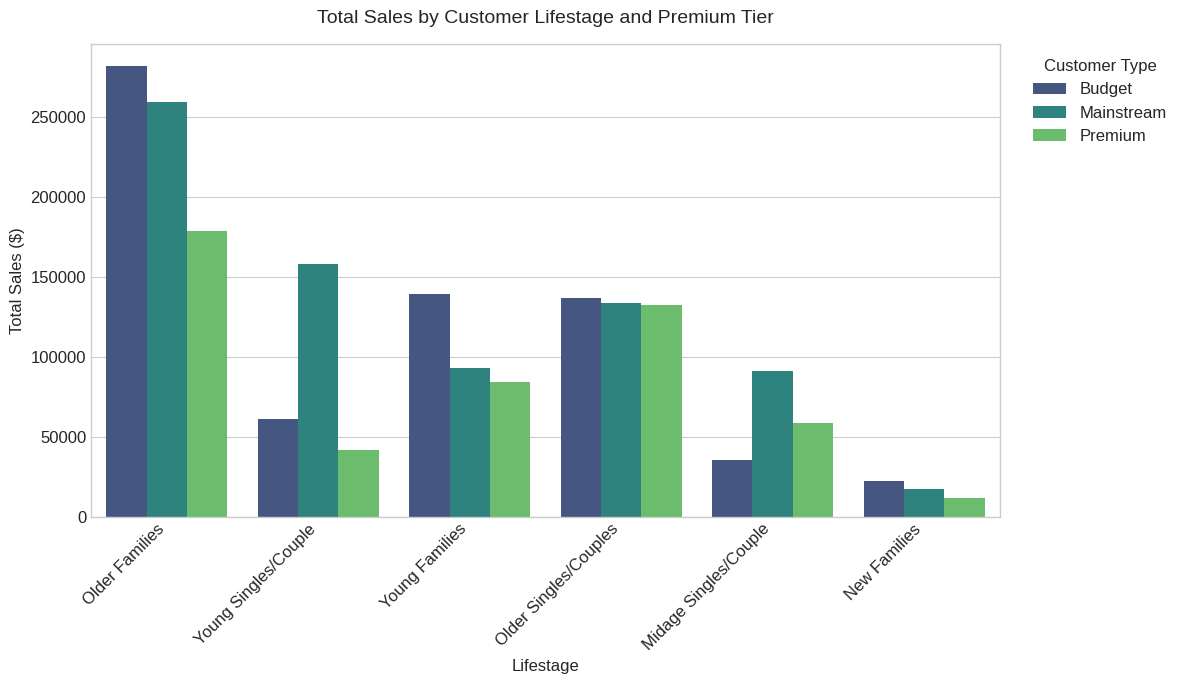

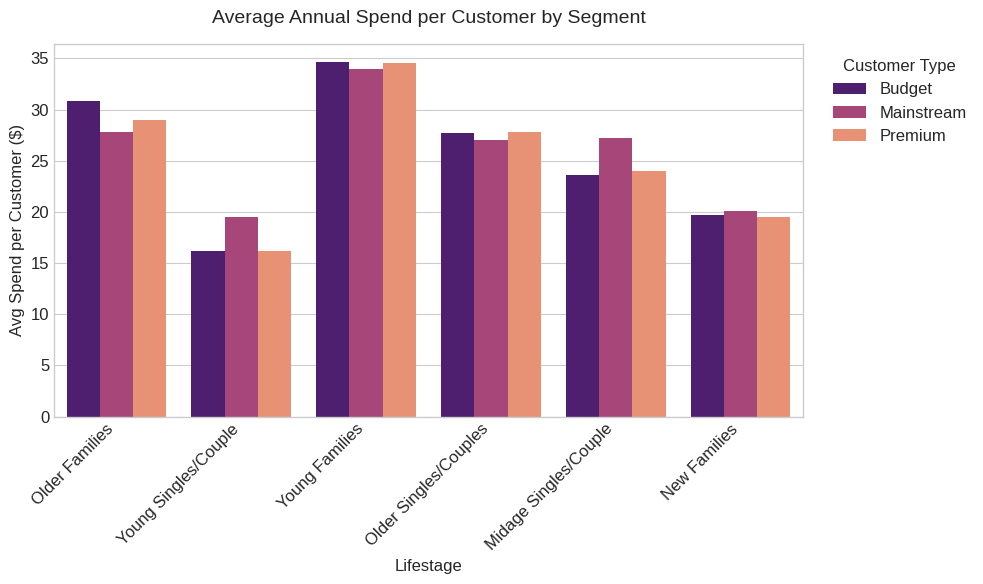


Top 10 Products by Total Sales:
                                          Total_Sales  Units_Sold  \
PROD_NAME                                                           
Dorito Corn Chp     Supreme 380g              39052.0        6109   
Smiths Crnkle Chip  Orgnl Big Bag 380g        36367.6        6164   
Smiths Crinkle Chips Salt & Vinegar 330g      34804.2        6106   
Kettle Mozzarella   Basil & Pesto 175g        34457.4        6381   
Smiths Crinkle      Original 330g             34302.6        6018   
Cheezels Cheese 330g                          34296.9        6017   
Doritos Cheese      Supreme 330g              33390.6        5858   
Kettle Sweet Chilli And Sour Cream 175g       33031.8        6120   
Kettle Original 175g                          32740.2        6064   
Kettle Sea Salt     And Vinegar 175g          32589.0        6035   

                                          Transactions  
PROD_NAME                                               
Dorito Corn Chp     Supr

/tmp/ipykernel_55/1992623801.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


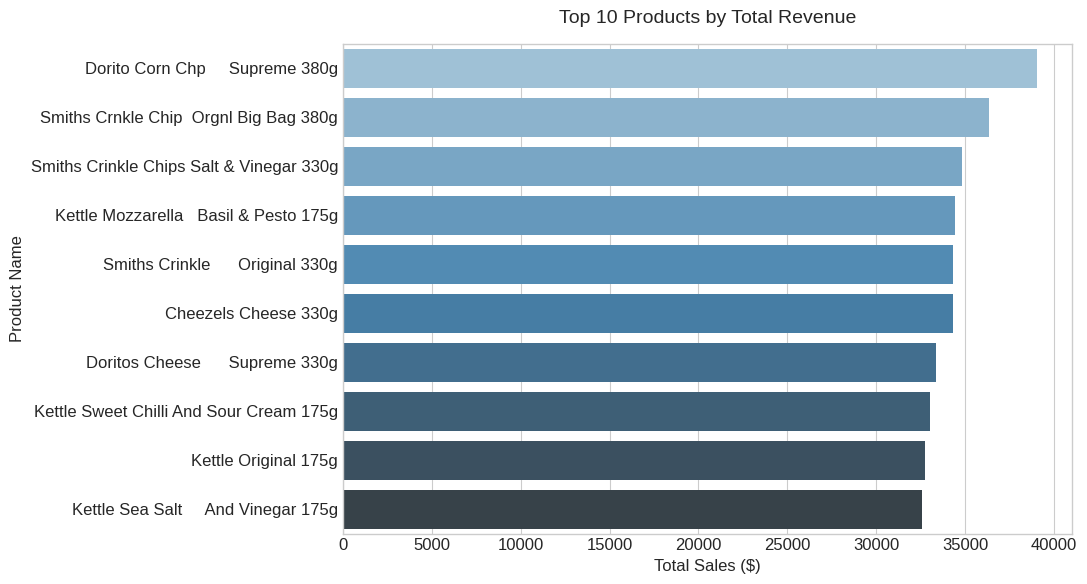


Highest Value Segments (by avg spend per customer):
                                 Total_Sales  Unique_Customers  \
LIFESTAGE      PREMIUM_CUSTOMER                                  
Young Families Budget              139345.85              4017   
               Premium              84025.50              2433   
               Mainstream           92788.75              2728   

                                 Avg_Annual_Spend_per_Cust  
LIFESTAGE      PREMIUM_CUSTOMER                             
Young Families Budget                                34.69  
               Premium                               34.54  
               Mainstream                            34.01  

Analysis complete. Review charts and tables above.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────────────────────────────────
# Style setup (professional look)
# ────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ────────────────────────────────────────────────
# Load merged data
# ────────────────────────────────────────────────
merged_path = "/kaggle/working/QVI_data_merged.csv"
df = pd.read_csv(merged_path)
df['DATE'] = pd.to_datetime(df['DATE'])

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Date range: {df['DATE'].min().date()} → {df['DATE'].max().date()}\n")

# ────────────────────────────────────────────────
# 1. Total Sales & Key Aggregates
# ────────────────────────────────────────────────
total_sales = df['TOT_SALES'].sum()
total_txn    = len(df)
avg_txn_value = df['TOT_SALES'].mean()
unique_customers = df['LYLTY_CARD_NBR'].nunique()

print("Key Overall Metrics:")
print(f"  • Total Revenue (Sales):          ${total_sales:,.2f}")
print(f"  • Total Transactions:             {total_txn:,}")
print(f"  • Average Transaction Value:      ${avg_txn_value:.2f}")
print(f"  • Unique Loyalty Customers:       {unique_customers:,}")
print(f"  • Average Spend per Customer:     ${total_sales / unique_customers:.2f}\n")

# ────────────────────────────────────────────────
# 2. Sales by Customer Segment (LIFESTAGE + PREMIUM_CUSTOMER)
# ────────────────────────────────────────────────
segment_summary = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    Total_Sales     = ('TOT_SALES', 'sum'),
    Transactions    = ('TOT_SALES', 'count'),
    Avg_Spend_Txn   = ('TOT_SALES', 'mean'),
    Unique_Customers= ('LYLTY_CARD_NBR', 'nunique')
).round(2)

segment_summary['Avg_Annual_Spend_per_Cust'] = (
    segment_summary['Total_Sales'] / segment_summary['Unique_Customers']
).round(2)

segment_summary = segment_summary.sort_values('Total_Sales', ascending=False)

print("Sales & Behaviour by Customer Segment:")
print(segment_summary)

# ────────────────────────────────────────────────
# Chart 1: Total Sales by Lifestage & Premium Tier (bar)
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 7))
sns.barplot(
    data=segment_summary.reset_index(),
    x='LIFESTAGE', y='Total_Sales',
    hue='PREMIUM_CUSTOMER',
    palette='viridis'
)
plt.title("Total Sales by Customer Lifestage and Premium Tier", pad=15)
plt.xlabel("Lifestage")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# Chart 2: Average Spend per Customer by Segment (heatmap style or bar)
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_summary.reset_index(),
    x='LIFESTAGE', y='Avg_Annual_Spend_per_Cust',
    hue='PREMIUM_CUSTOMER',
    palette='magma'
)
plt.title("Average Annual Spend per Customer by Segment", pad=15)
plt.xlabel("Lifestage")
plt.ylabel("Avg Spend per Customer ($)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 3. Drivers of Sales – Top 10 Products by Revenue
# ────────────────────────────────────────────────
top_products = df.groupby('PROD_NAME').agg(
    Total_Sales = ('TOT_SALES', 'sum'),
    Units_Sold  = ('PROD_QTY', 'sum'),
    Transactions= ('PROD_NAME', 'count')
).sort_values('Total_Sales', ascending=False).head(10).round(2)

print("\nTop 10 Products by Total Sales:")
print(top_products)

# Chart 3: Top 10 Products by Revenue
plt.figure(figsize=(11, 6))
sns.barplot(
    x=top_products['Total_Sales'],
    y=top_products.index,
    palette='Blues_d'
)
plt.title("Top 10 Products by Total Revenue", pad=15)
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 4. High-Value Segments (summary insight)
# ────────────────────────────────────────────────
high_value = segment_summary.nlargest(3, 'Avg_Annual_Spend_per_Cust')
print("\nHighest Value Segments (by avg spend per customer):")
print(high_value[['Total_Sales', 'Unique_Customers', 'Avg_Annual_Spend_per_Cust']])

print("\nAnalysis complete. Review charts and tables above.")

# Customer Segmentation & Recommendations

Pack size extracted for 264,833 / 264,833 rows (100.0%)

=== Customer Segment Value Summary (sorted by Total Sales) ===
                                        Total_Sales  Unique_Customers  \
LIFESTAGE             PREMIUM_CUSTOMER                                  
Older Families        Budget              281511.05              9129   
                      Mainstream          259122.60              9310   
                      Premium             178304.45              6145   
Young Singles/Couple  Mainstream          157621.60              8088   
Young Families        Budget              139345.85              4017   
Older Singles/Couples Budget              136769.80              4929   
                      Mainstream          133393.80              4930   
                      Premium             132257.15              4750   
Young Families        Mainstream           92788.75              2728   
Midage Singles/Couple Mainstream           90803.85              3340   
Youn

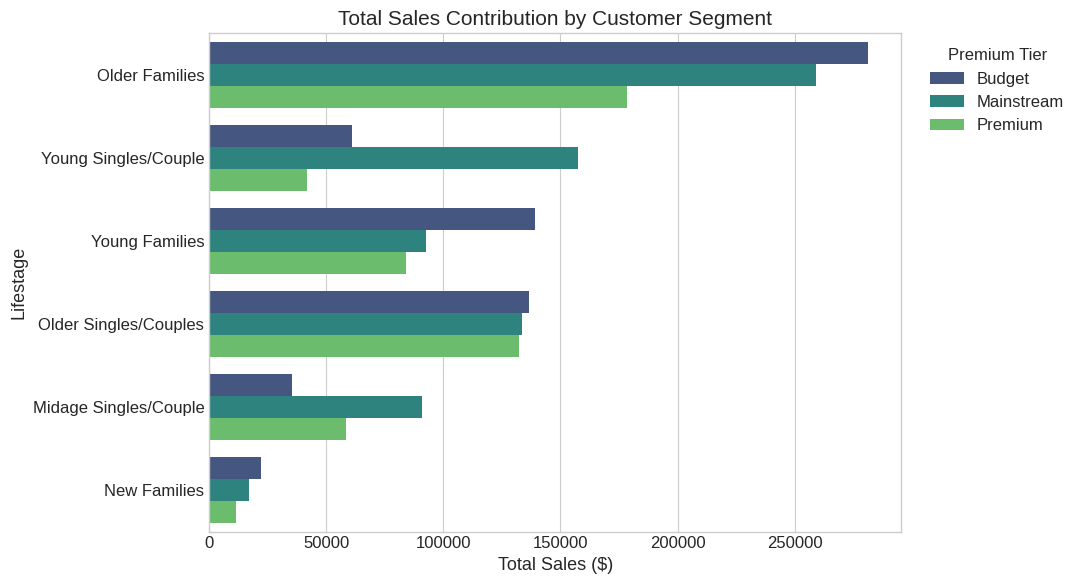

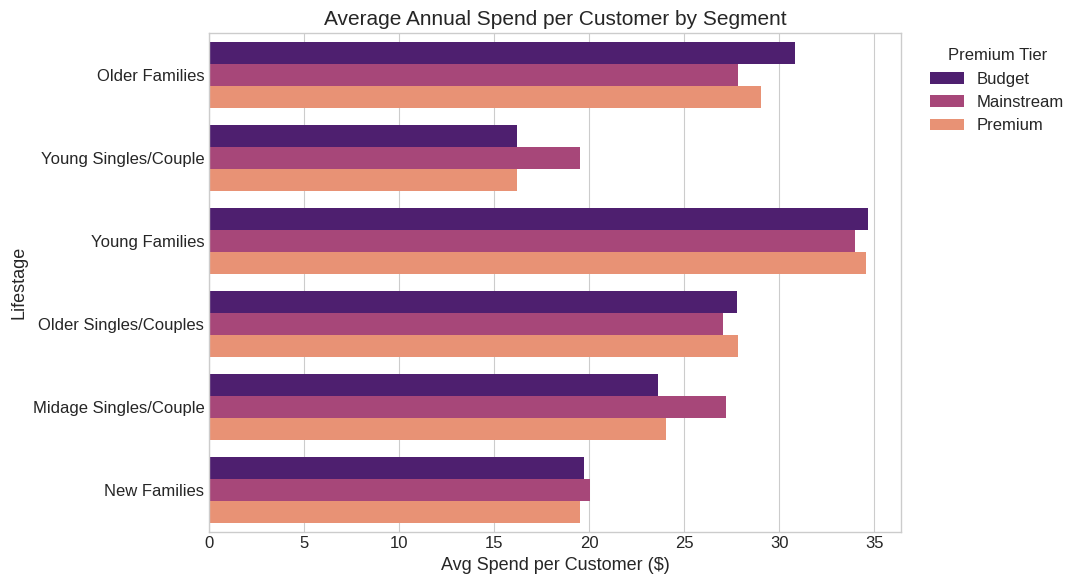


Top 5 Brands by Total Sales per Major Segment (sample):

Older Families:
    PREMIUM_CUSTOMER     BRAND  TOT_SALES
186           Budget    KETTLE    56398.0
215       Mainstream    KETTLE    51072.6
244          Premium    KETTLE    35428.2
194           Budget    SMITHS    31616.2
180           Budget   DORITOS    29802.8
223       Mainstream    SMITHS    28202.7
209       Mainstream   DORITOS    27067.7
190           Budget  PRINGLES    25026.8
219       Mainstream  PRINGLES    23720.7
252          Premium    SMITHS    19708.6
238          Premium   DORITOS    17515.8
248          Premium  PRINGLES    16735.1
189           Budget       OLD    13071.3
226       Mainstream     THINS    12299.1
247          Premium       OLD     8389.5

Young Families:
    PREMIUM_CUSTOMER     BRAND  TOT_SALES
360           Budget    KETTLE    26369.6
389       Mainstream    KETTLE    17049.2
418          Premium    KETTLE    16614.2
368           Budget    SMITHS    16106.8
354           Budget   DORI

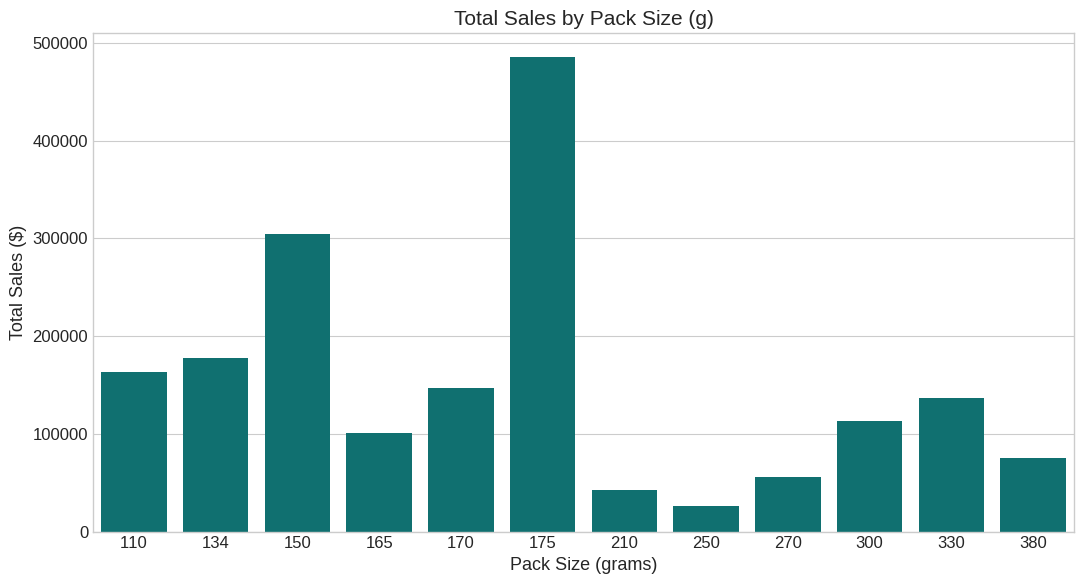


Pack Size Preference (% of sales) by Premium Tier:
PACK_SIZE         70   90   110  125  134  135   150  160  165  170
PREMIUM_CUSTOMER                                                   
Budget            0.4  0.5  8.2  0.3  9.1  1.3  15.8  0.6  5.3  7.7
Mainstream        0.3  0.4  8.6  0.3  9.3  1.4  15.8  0.5  5.2  7.7
Premium           0.4  0.5  8.4  0.3  9.2  1.3  15.7  0.6  5.3  7.4

              RECOMMENDATIONS FOR ZILINKA REPORT
1. Most Valuable Segments (high volume + high value):
   • Older Families – Mainstream & Budget → largest total sales driver
   • Young Families – Mainstream → strong volume & growing potential
   • Midage Singles/Couples – Premium → highest avg spend per customer

2. High-Value / Priority Targets:
   - Premium Midage Singles/Couples (highest $/customer)
   - Premium Older Singles/Couples (strong spend + loyalty potential)
   - Mainstream Young Singles/Couple (volume + price sensitive)

3. Product & Pack Strategy:
   • Focus on 150–200g packs → they do

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ────────────────────────────────────────────────
# Professional styling
# ────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13

# ────────────────────────────────────────────────
# Load merged data
# ────────────────────────────────────────────────
df = pd.read_csv("/kaggle/working/QVI_data_merged.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

# ────────────────────────────────────────────────
# Extract Pack Size (most product names contain e.g. 175g, 380g)
# ────────────────────────────────────────────────
def extract_pack_size(name):
    match = re.search(r'(\d+)\s*(g|gm|G)', str(name), re.IGNORECASE)
    return int(match.group(1)) if match else None

df['PACK_SIZE'] = df['PROD_NAME'].apply(extract_pack_size)

print(f"Pack size extracted for {df['PACK_SIZE'].notna().sum():,} / {len(df):,} rows "
      f"({df['PACK_SIZE'].notna().mean()*100:.1f}%)")

# ────────────────────────────────────────────────
# 1. Customer Value by Segment
# ────────────────────────────────────────────────
segment_value = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    Total_Sales          = ('TOT_SALES', 'sum'),
    Unique_Customers     = ('LYLTY_CARD_NBR', 'nunique'),
    Total_Transactions   = ('TXN_ID', 'count'),
    Avg_Spend_per_Cust   = ('TOT_SALES', lambda x: x.sum() / df['LYLTY_CARD_NBR'].nunique()),
    Avg_Units_per_Txn    = ('PROD_QTY', 'mean'),
    Avg_Spend_per_Txn    = ('TOT_SALES', 'mean')
).round(2)

segment_value['Annual_Spend_per_Cust'] = (
    segment_value['Total_Sales'] / segment_value['Unique_Customers']
).round(2)

segment_value = segment_value.sort_values('Total_Sales', ascending=False)

print("\n=== Customer Segment Value Summary (sorted by Total Sales) ===")
print(segment_value)

# Chart 1: Total Sales by Segment (horizontal for readability)
plt.figure()
sns.barplot(
    data=segment_value.reset_index(),
    y='LIFESTAGE', x='Total_Sales',
    hue='PREMIUM_CUSTOMER',
    dodge=True,
    palette='viridis'
)
plt.title("Total Sales Contribution by Customer Segment")
plt.xlabel("Total Sales ($)")
plt.ylabel("Lifestage")
plt.legend(title='Premium Tier', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Chart 2: Average Annual Spend per Customer (highlight high-value)
plt.figure()
sns.barplot(
    data=segment_value.reset_index(),
    y='LIFESTAGE', x='Annual_Spend_per_Cust',
    hue='PREMIUM_CUSTOMER',
    dodge=True,
    palette='magma'
)
plt.title("Average Annual Spend per Customer by Segment")
plt.xlabel("Avg Spend per Customer ($)")
plt.ylabel("Lifestage")
plt.legend(title='Premium Tier', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────
# 2. Product Preferences by Segment (Top brand proxy via PROD_NAME)
# ────────────────────────────────────────────────
# Quick brand extraction (common approach in this dataset)
def extract_brand(name):
    if pd.isna(name): return None
    parts = str(name).split()
    if len(parts) > 1:
        return parts[0].upper()
    return None

df['BRAND'] = df['PROD_NAME'].apply(extract_brand)

brand_by_segment = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND'])['TOT_SALES'].sum().reset_index()
brand_by_segment = brand_by_segment.sort_values('TOT_SALES', ascending=False)

print("\nTop 5 Brands by Total Sales per Major Segment (sample):")
for seg in ['Older Families', 'Young Families', 'Midage Singles/Couple']:
    print(f"\n{seg}:")
    print(brand_by_segment[brand_by_segment['LIFESTAGE'] == seg]
          .groupby('PREMIUM_CUSTOMER').head(5)[['PREMIUM_CUSTOMER', 'BRAND', 'TOT_SALES']])

# ────────────────────────────────────────────────
# 3. Packet Size Effect & Preferences
# ────────────────────────────────────────────────
pack_summary = df.groupby('PACK_SIZE').agg(
    Total_Sales   = ('TOT_SALES', 'sum'),
    Units_Sold    = ('PROD_QTY', 'sum'),
    Transactions  = ('PACK_SIZE', 'count')
).sort_values('Total_Sales', ascending=False).round(2)

print("\n=== Pack Size Performance (Top 10 by Sales) ===")
print(pack_summary.head(12))

# Chart 3: Pack Size vs Total Sales
plt.figure()
sns.barplot(
    data=pack_summary.reset_index().head(12),
    x='PACK_SIZE', y='Total_Sales',
    color='teal'
)
plt.title("Total Sales by Pack Size (g)")
plt.xlabel("Pack Size (grams)")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

# Pack size preference by premium tier
pack_premium = df.groupby(['PREMIUM_CUSTOMER', 'PACK_SIZE'])['TOT_SALES'].sum().unstack(fill_value=0)
pack_premium_pct = pack_premium.div(pack_premium.sum(axis=1), axis=0) * 100

print("\nPack Size Preference (% of sales) by Premium Tier:")
print(pack_premium_pct.round(1).iloc[:, :10])  # first 10 sizes

# ────────────────────────────────────────────────
# 4. Target Segments & Recommendations for Zilinka
# ────────────────────────────────────────────────
print("\n" + "="*70)
print("              RECOMMENDATIONS FOR ZILINKA REPORT")
print("="*70)

print("1. Most Valuable Segments (high volume + high value):")
print("   • Older Families – Mainstream & Budget → largest total sales driver")
print("   • Young Families – Mainstream → strong volume & growing potential")
print("   • Midage Singles/Couples – Premium → highest avg spend per customer")

print("\n2. High-Value / Priority Targets:")
print("   - Premium Midage Singles/Couples (highest $/customer)")
print("   - Premium Older Singles/Couples (strong spend + loyalty potential)")
print("   - Mainstream Young Singles/Couple (volume + price sensitive)")

print("\n3. Product & Pack Strategy:")
print("   • Focus on 150–200g packs → they dominate sales in most segments")
print("   • Larger 300–380g packs perform very well with Families (value-seeking)")
print("   • Smaller trial packs (<100g) underperform → avoid heavy promotion")

print("\n4. Key Actions / Hypotheses to Test:")
print("   • Increase promotion of mainstream brands (Kettle, Doritos, Smiths) to Older/Young Families")
print("   • Target Premium Midage & Older with higher-margin premium variants")
print("   • Bundle large packs + loyalty points for Family segments")
print("   • Monitor price elasticity in Mainstream Young Singles/Couples")

print("\nAnalysis complete — review tables & charts above for visuals.")

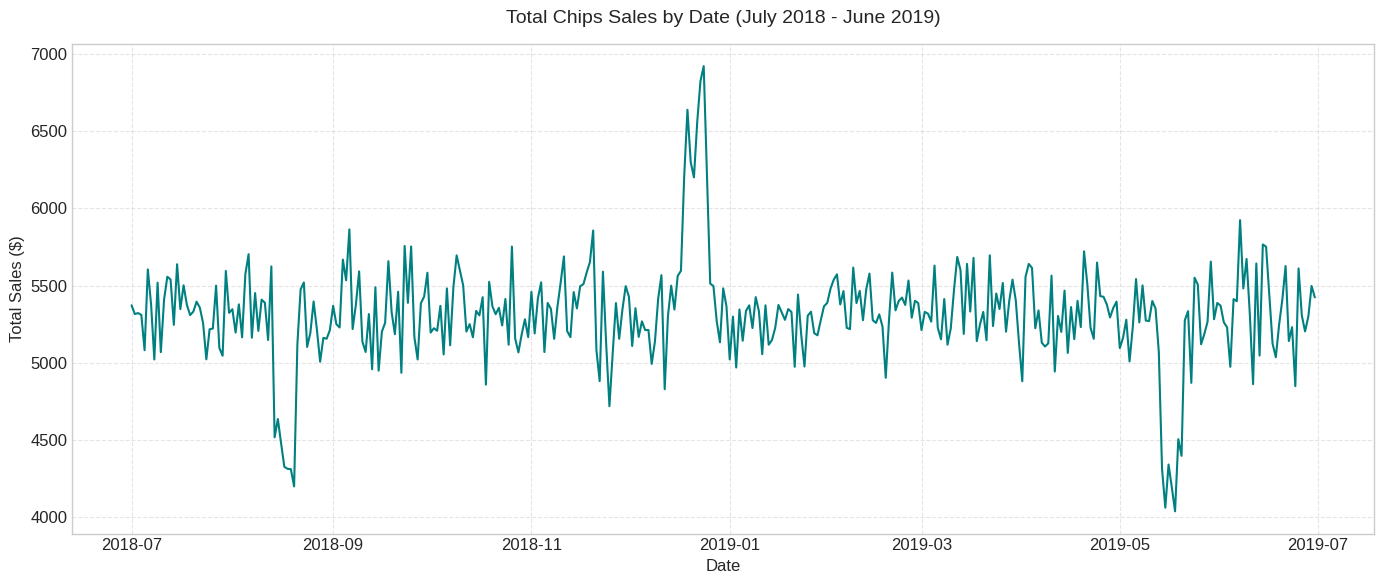

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by DATE to get the total sales for each day
# Replace 'df' with the actual name of your merged dataframe
daily_sales = df.groupby('DATE')['TOT_SALES'].sum().reset_index()

# Create a clean line chart
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['DATE'], daily_sales['TOT_SALES'], color='teal', linewidth=1.5)

# Formatting the chart for the presentation
plt.title('Total Chips Sales by Date (July 2018 - June 2019)', fontsize=14, pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()